# **Simple statistics**
## Image Processing and Computer Vision


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.stats import norm

## Histogram

### Grayscale images

**Histogram code**


Syntax: 
- cv2.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])


Parameters:
- **images**: list of images as numpy arrays. All images must be of the same dtype and same size.
- **channels**: list of the channels used to calculate the histograms. if the input is a *grayscale* image, its value is [0]. For *colour* images, you can pass [0], [1] or [2] to calculate histograms of blue, green or red channels respectively.
- **mask**: optional mask (8 bit array) of the same size as the input image.
- **histSize**: histogram sizes in each dimension
- **ranges**: Array of the dims arrays of the histogram bin boundaries in each dimension
- **hist**: Output histogram
- **accumulate**: accumulation flag, enables to compute a single histogram from several sets of arrays.

In [3]:
GRAYSCALE_IMG_PATH = "./img/bolts.png"

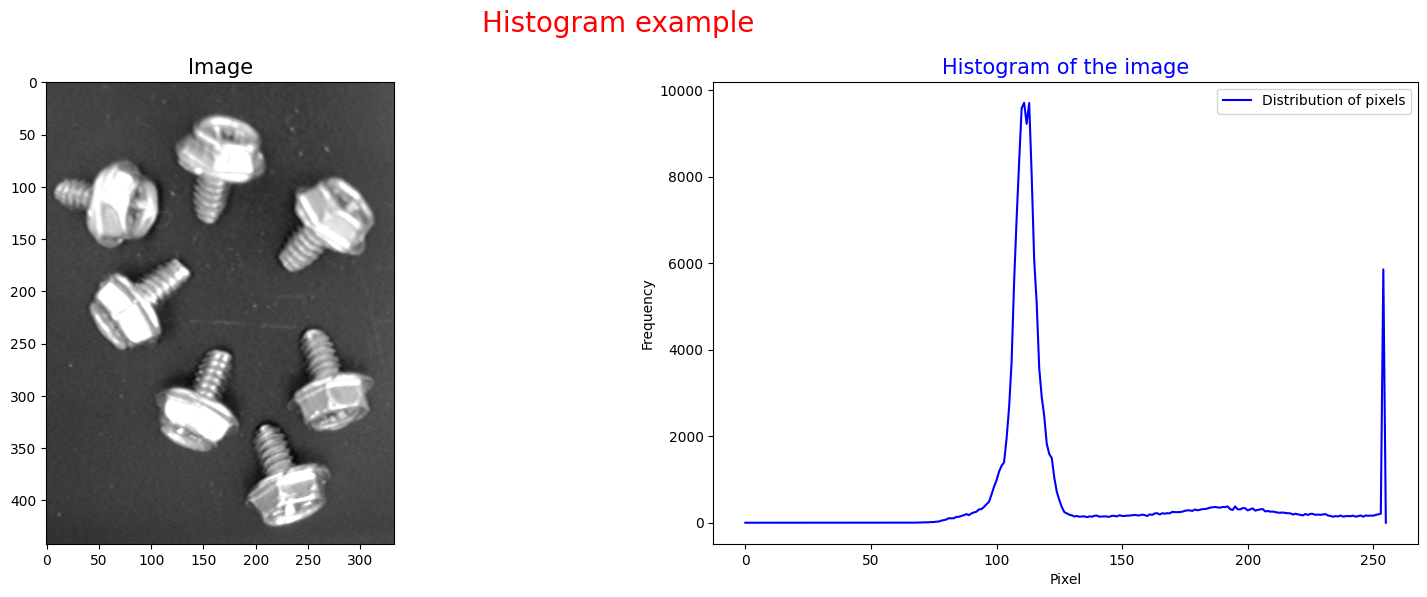

In [ ]:
# PARAMETERS HISTOGRAM
num_bins = 256
pixel_range = [0, 256]

img = cv2.imread(GRAYSCALE_IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

hist = cv2.calcHist([img], [0], None, [num_bins], pixel_range)

# SHOW HISTOGRAM
plt.figure(figsize=(20,6))
plt.suptitle("Histogram example", fontsize = 20, color = "red", y = 1)

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Image", fontsize = 15, color = "black")

plt.subplot(1,2,2)
plt.plot(hist, label = "Distribution of pixels", color = "blue", alpha = 1)
plt.title("Histogram of the image", fontsize = 15, color = "blue")
plt.xlabel("Pixel")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### RGB images

In [5]:
RGB_IMAGE_PATH = "./img/ferrari.jpg"

#### Separate histograms

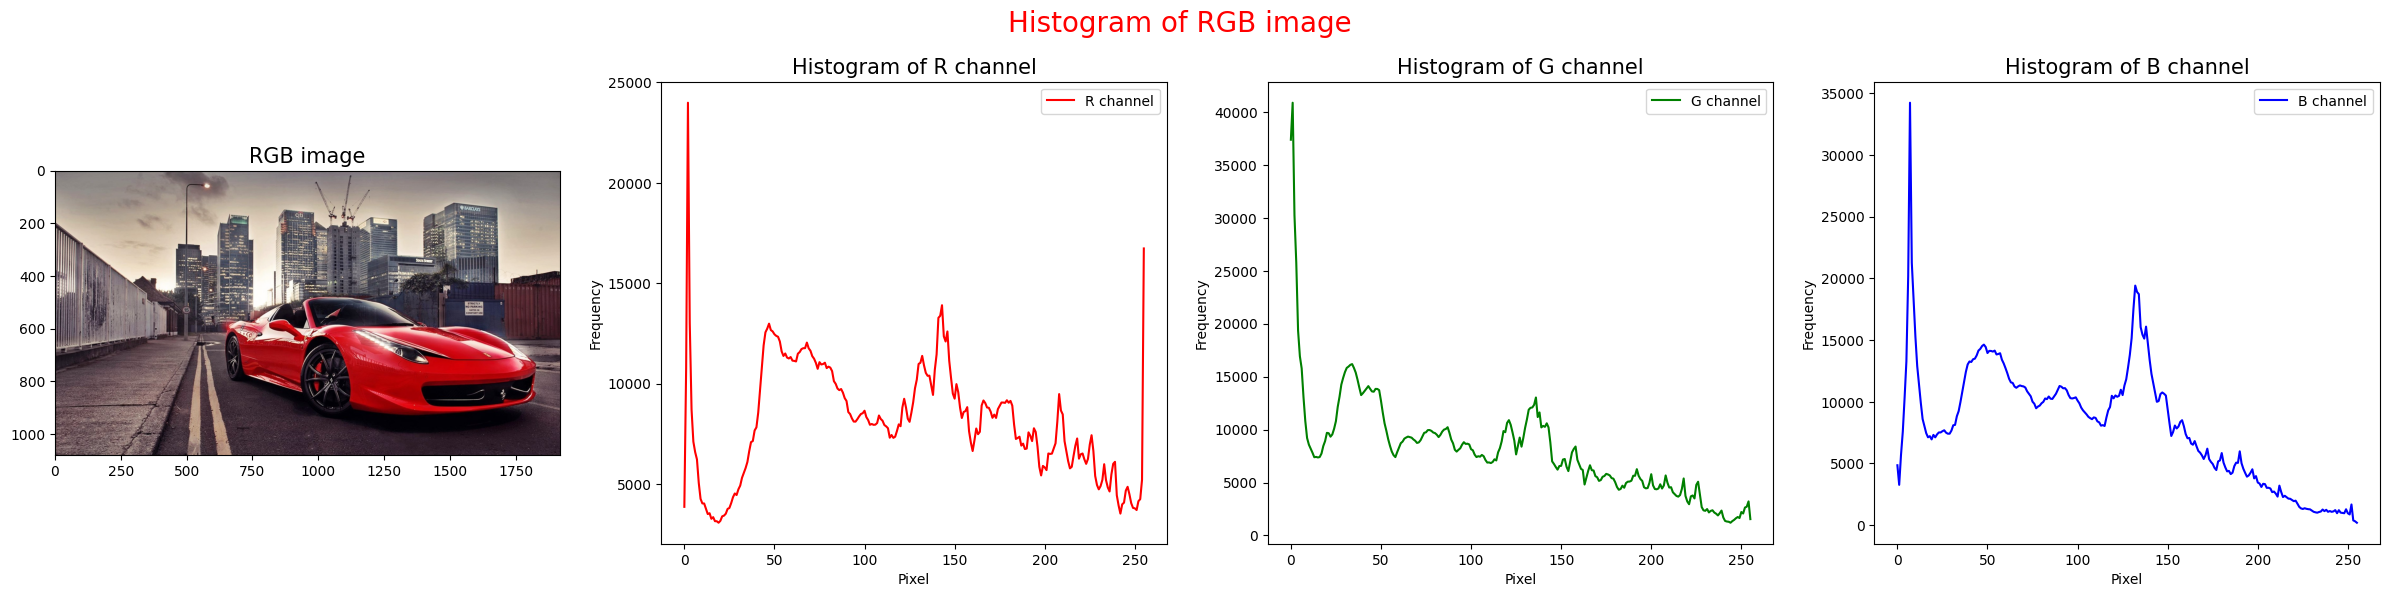

In [ ]:
# PARAMETERS HISTOGRAM
num_bins = 256
pixel_range = [0, 256]

img_rgb = cv2.imread(RGB_IMAGE_PATH)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

# Compute the histogram for the image
title_r = "Histogram channel R"
hist_r = cv2.calcHist([img_rgb],[0],None,[num_bins],pixel_range)

title_g = "Histogram channel G"
hist_g = cv2.calcHist([img_rgb],[1],None,[num_bins],pixel_range)

title_b = "Histogram channel B"
hist_b = cv2.calcHist([img_rgb],[2],None,[num_bins],pixel_range)

title_hist = "Histogram of RGB image"

# SHOW HISTOGRAM
plt.figure(figsize=(30,6))
plt.suptitle(title_hist, fontsize = 20, color = "red", y = 1)

# RGB image
plt.subplot(1,4,1)
plt.imshow(img_rgb, cmap="gray")
plt.title("RGB image", fontsize = 15, color = "black")

# Histogram of R channel
plt.subplot(1,4,2)
plt.plot(hist_r, label = "R channel", color = "red", alpha = 1)
plt.title("Histogram of R channel", fontsize = 15, color = "black")
plt.xlabel("Pixel")
plt.ylabel("Frequency")
plt.legend()

# Histogram of G channel
plt.subplot(1,4,3)
plt.plot(hist_g, label = "G channel", color = "green", alpha = 1)
plt.title("Histogram of G channel", fontsize = 15, color = "black")
plt.xlabel("Pixel")
plt.ylabel("Frequency")
plt.legend()

# Histogram of B channel
plt.subplot(1,4,4)
plt.plot(hist_b, label = "B channel", color = "blue", alpha = 1)
plt.title("Histogram of B channel", fontsize = 15, color = "black")
plt.xlabel("Pixel")
plt.ylabel("Frequency")
plt.legend()

plt.show()

#### Unified histogram

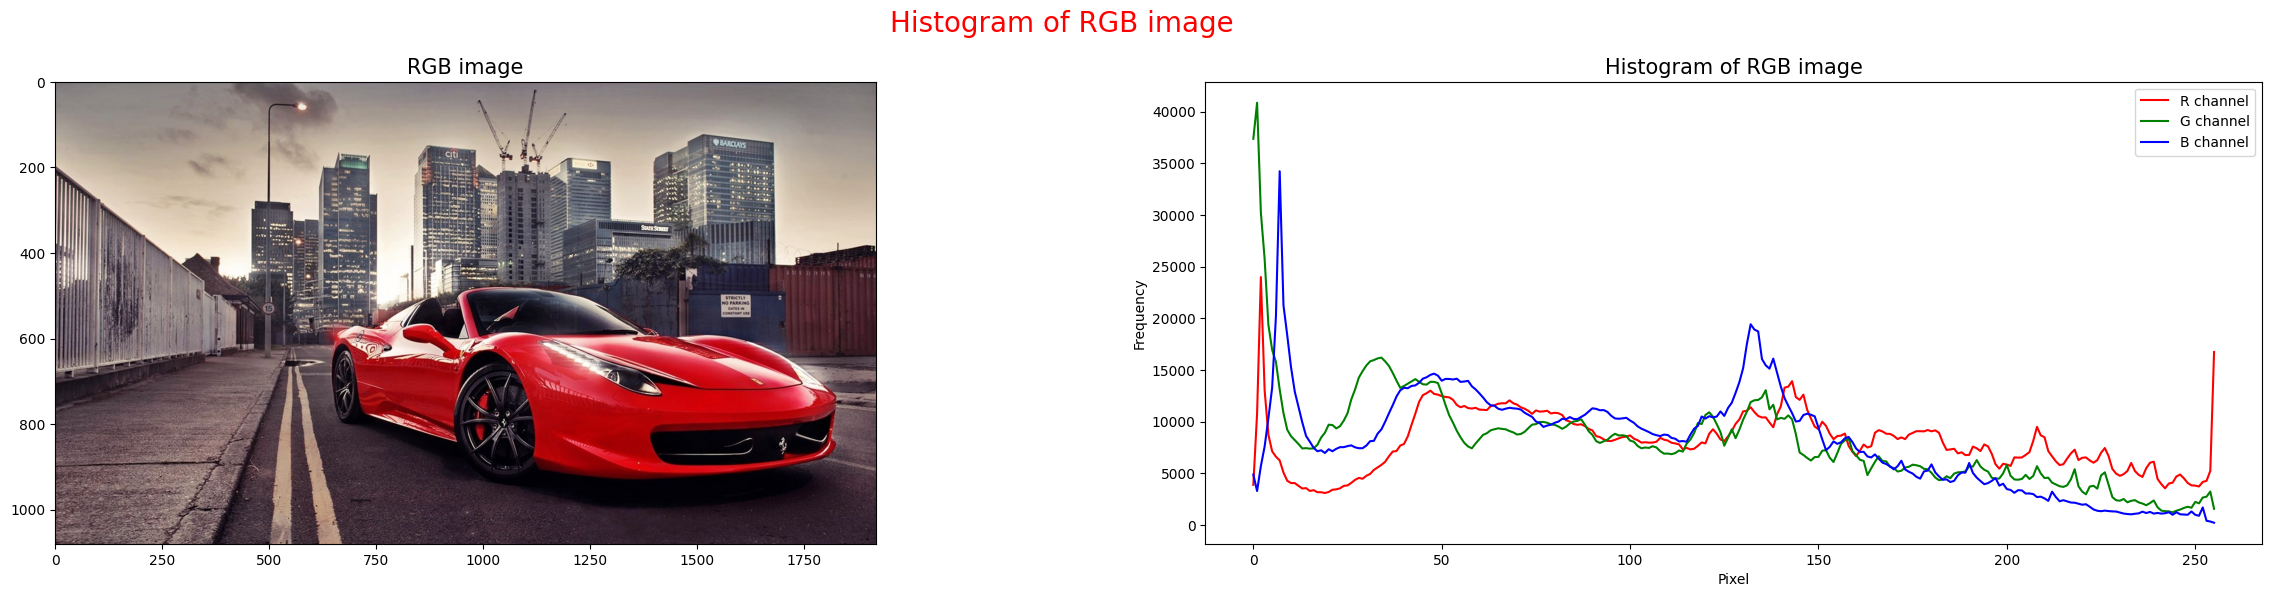

In [ ]:
# PARAMETERS HISTOGRAM
num_bins = 256
pixel_range = [0, 256]

img_rgb = cv2.imread(RGB_IMAGE_PATH)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

# Compute the histogram for the image
title_r = "Histogram channel R"
hist_r = cv2.calcHist([img_rgb],[0],None,[num_bins],pixel_range)

title_g = "Histogram channel G"
hist_g = cv2.calcHist([img_rgb],[1],None,[num_bins],pixel_range)

title_b = "Histogram channel B"
hist_b = cv2.calcHist([img_rgb],[2],None,[num_bins],pixel_range)

title_hist = "Histogram of RGB image"

# SHOW HISTOGRAM
plt.figure(figsize=(30,6))
plt.suptitle(title_hist, fontsize = 20, color = "red", y = 1)

# RGB image
plt.subplot(1,2,1)
plt.imshow(img_rgb, cmap="gray")
plt.title("RGB image", fontsize = 15, color = "black")

# Histogram of R channel
plt.subplot(1,2,2)
plt.plot(hist_r, label = "R channel", color = "red", alpha = 1)
plt.plot(hist_g, label = "G channel", color = "green", alpha = 1)
plt.plot(hist_b, label = "B channel", color = "blue", alpha = 1)

plt.title("Histogram of RGB image", fontsize = 15, color = "black")
plt.xlabel("Pixel")
plt.ylabel("Frequency")
plt.legend()

plt.show()

## Global Stats

Global metrics to study the images

Definition: 
- The function cv::meanStdDev calculates the mean and the standard deviation M of array elements independently for each channel and returns it via the output parameters:

Syntax:
- cv.meanStdDev(src[, mean[, stddev[, mask]]]) ->	mean, stddev

Parameters:
- **src**: input image

Mean: 131.53286997404643
Standard deviation: 42.64599436809726
Min value: 63
Max value: 254


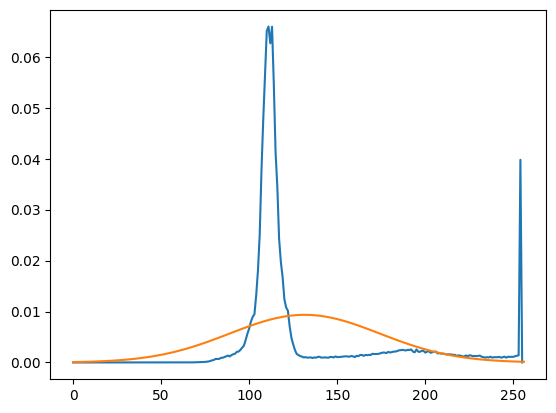

In [ ]:
GRAYSCALE_IMG_PATH = "./img/bolts.png"

# PARAMETERS HISTOGRAM
num_bins = 256
pixel_range = [0, 256]

img = cv2.imread(GRAYSCALE_IMG_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Calculus
mean, stddev = cv2.meanStdDev(img)
mean = mean[0][0]
stddev = stddev[0][0]
min = np.min(img)
max = np.max(img)

# Print values
print(f"Mean: {mean}")
print(f"Standard deviation: {stddev}")
print(f"Min value: {min}")
print(f"Max value: {max}")

hist = cv2.calcHist([img], [0], None, [num_bins], pixel_range)
hist /= hist.sum() # Normalize hist for better print with gaussian distribution

# Plot gaussian distribution + hist
xmin, xmax = (0, 256)
x = np.linspace(xmin, xmax, 100)
y = norm.pdf(x, mean, stddev)

plt.plot(hist)
plt.plot(x,y)
plt.show()
